# 02 — EDA: Engineered Customer-Level Data

EDA on the engineered dataset produced by `conventional_approach/feature_engineering.py`. Each row corresponds to a single customer's **1st purchase**, plus a churn label defined as: `1` if no 2nd purchase exists, or the 2nd purchase is more than 365 days after the 1st; `0` otherwise. Customers whose 1st purchase falls within the last 365 days of the dataset are excluded upstream.

Features include the 1st-purchase row, extracted date parts (weekday, month, year, hour, time-of-day, holiday flag), a derived `transaction_amount = product_price * quantity`, and dataset-wide week-over-week % differences in total quantity and amount. The original `total_purchase_amount` is dropped (not known at acquisition).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
DATA_DIR = Path('..') / 'data' / 'raw'

pd.set_option('display.max_columns', 100)


## 1. Load Processed Data

Loads `data/processed/customers.csv` — one row per customer, generated by running `feature_engineering.py`.

In [11]:
PROCESSED_DIR = Path('..') / 'data' / 'processed'
customers = pd.read_csv(PROCESSED_DIR / 'customers.csv', index_col='customer_id')
customers['purchase_date'] = pd.to_datetime(customers['purchase_date'])

ID_COLS          = ['customer_name']
CATEGORICAL_COLS = ['product_category', 'payment_method', 'gender',
                    'purchase_weekday', 'purchase_month',
                    'purchase_time_of_day', 'is_holiday']
NUMERIC_COLS     = [c for c in customers.columns
                    if c not in ID_COLS + CATEGORICAL_COLS + ['purchase_date']]

for col in CATEGORICAL_COLS:
    customers[col] = customers[col].astype('category')

print(f'Shape              : {customers.shape}')
print(f'Churn rate         : {customers["churn"].mean():.2%}')
print(f'Purchase date range: {customers["purchase_date"].min().date()} -> {customers["purchase_date"].max().date()}')

print(f'\nVariable groups:')
print(f'  ID ({len(ID_COLS)})         : {ID_COLS}')
print(f'  Categorical ({len(CATEGORICAL_COLS)}) : {CATEGORICAL_COLS}')
print(f'  Numeric ({len(NUMERIC_COLS)})    : {NUMERIC_COLS}')

print(f'\nMissing values (non-zero only):')
miss = customers.isnull().sum()
print(miss[miss > 0].to_string() if (miss > 0).any() else '  none')

customers.head()

Shape              : (48753, 19)
Churn rate         : 25.78%
Purchase date range: 2020-01-01 -> 2022-09-13

Variable groups:
  ID (1)         : ['customer_name']
  Categorical (7) : ['product_category', 'payment_method', 'gender', 'purchase_weekday', 'purchase_month', 'purchase_time_of_day', 'is_holiday']
  Numeric (10)    : ['product_price', 'quantity', 'customer_age', 'returns', 'churn', 'transaction_amount', 'purchase_year', 'purchase_hour', 'pct_diff_quantity_vs_prev_week', 'pct_diff_amount_vs_prev_week']

Missing values (non-zero only):
returns                           9321
pct_diff_quantity_vs_prev_week    2152
pct_diff_amount_vs_prev_week      2152


,purchase_date,product_category,product_price,quantity,payment_method,customer_age,returns,customer_name,gender,churn,transaction_amount,purchase_weekday,purchase_month,purchase_year,purchase_hour,purchase_time_of_day,is_holiday,pct_diff_quantity_vs_prev_week,pct_diff_amount_vs_prev_week
customer_id,,,,,,,,,,,,,,,,,,,
1,2020-03-04 10:26:02,Clothing,205,5,Cash,67,NaN,Dominic Cline,Female,1,1025,Wednesday,March,2020,10,Morning,False,1.799856,3.050366
2,2020-07-31 16:27:41,Electronics,408,2,PayPal,42,0.0,Crystal Day,Female,1,816,Friday,July,2020,16,Afternoon,False,8.172043,8.083428
3,2020-01-19 00:03:00,Electronics,452,5,Credit Card,31,NaN,Joseph Perez,Male,0,2260,Sunday,January,2020,0,Night,False,NaN,NaN
4,2020-10-12 22:03:10,Electronics,77,3,Cash,37,0.0,Wyatt Love,Male,0,231,Monday,October,2020,22,Night,True,-9.090909,-0.624517
5,2020-04-08 21:57:19,Home,377,1,PayPal,24,NaN,Shannon Hoffman,Female,0,377,Wednesday,April,2020,21,Evening,False,-4.021609,0.653217


## 2. Correlation Heatmap

Pairwise correlations across the numeric 1st-purchase features and the churn label.

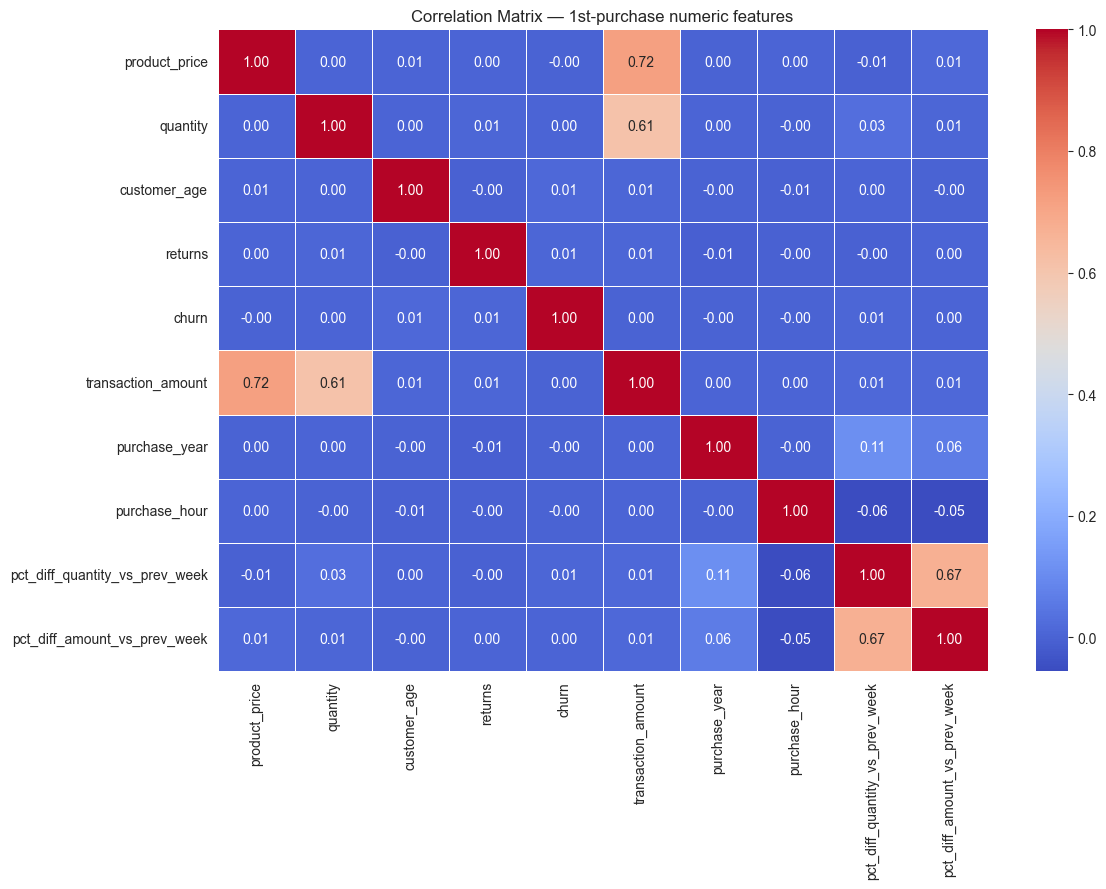

In [12]:
cust_num = customers[NUMERIC_COLS]

plt.figure(figsize=(12, 9))
sns.heatmap(cust_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — 1st-purchase numeric features')
plt.tight_layout()
plt.show()

## 3. Numeric Feature Distributions vs Churn

For each numeric feature, compares the distribution of churned vs retained customers (histogram + boxplot). `pct_diff_*` columns are clipped to the 1st–99th percentile for the histogram only, since the prior-week denominator can be small and the raw distribution is heavy-tailed.

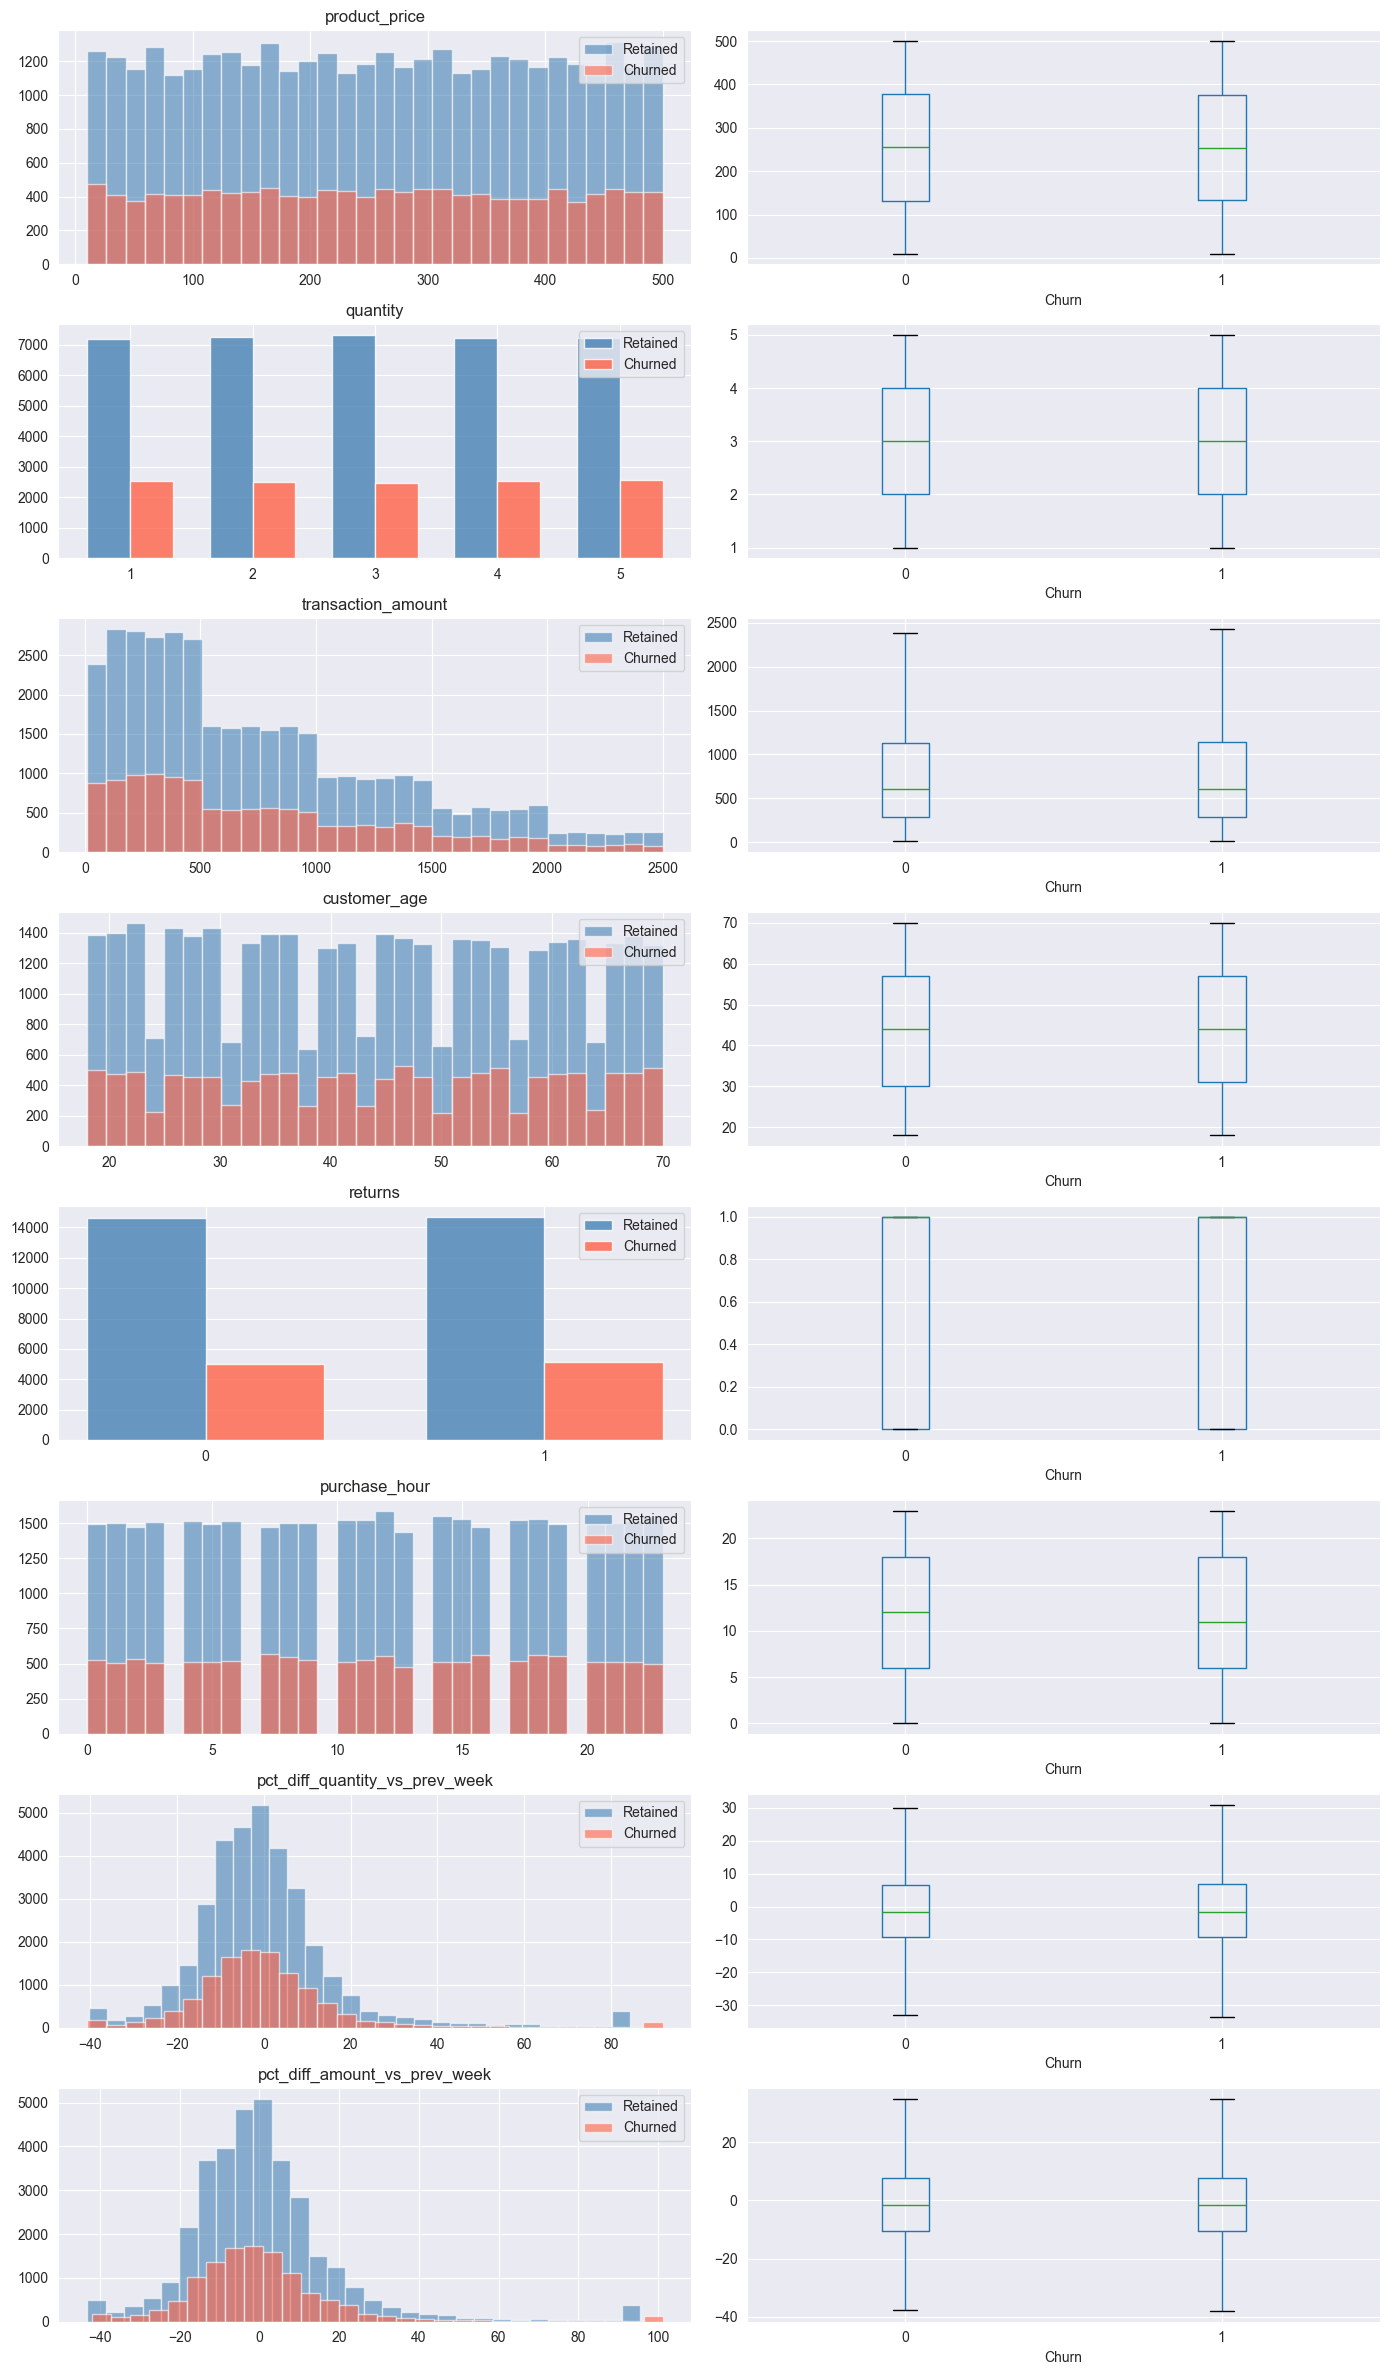

In [13]:
target_col    = 'churn'
NUMERIC_FEATS = ['product_price', 'quantity', 'transaction_amount',
                 'customer_age', 'returns', 'purchase_hour',
                 'pct_diff_quantity_vs_prev_week', 'pct_diff_amount_vs_prev_week']
DISCRETE_COLS = {'quantity', 'returns'}

fig, axes = plt.subplots(len(NUMERIC_FEATS), 2, figsize=(14, len(NUMERIC_FEATS) * 3))

for i, col in enumerate(NUMERIC_FEATS):
    ax_hist, ax_box = axes[i, 0], axes[i, 1]

    if col in DISCRETE_COLS:
        vals = sorted(customers[col].dropna().unique())
        x, w = np.arange(len(vals)), 0.35
        for j, (churn_val, label, color) in enumerate([(0,'Retained','steelblue'), (1,'Churned','tomato')]):
            counts = [customers[customers[target_col] == churn_val][col].value_counts().get(v, 0) for v in vals]
            ax_hist.bar(x + j * w, counts, width=w, label=label, color=color, alpha=0.8)
        ax_hist.set_xticks(x + w / 2)
        ax_hist.set_xticklabels([int(v) for v in vals])
    else:
        for churn_val, label, color in [(0,'Retained','steelblue'), (1,'Churned','tomato')]:
            subset = customers[customers[target_col] == churn_val][col].dropna()
            if col.startswith('pct_diff') and len(subset) > 0:
                lo, hi = subset.quantile([0.01, 0.99])
                subset = subset.clip(lo, hi)
            ax_hist.hist(subset, bins=30, alpha=0.6, label=label, color=color)

    ax_hist.set_title(col)
    ax_hist.legend()

    customers.boxplot(column=col, by=target_col, ax=ax_box, showfliers=False)
    ax_box.set_title('')
    ax_box.set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Categorical Features — Churn Rate

For each categorical feature (including the extracted date parts from `purchase_date`), shows the churn rate within each level. The dashed line marks the overall churn rate for reference.

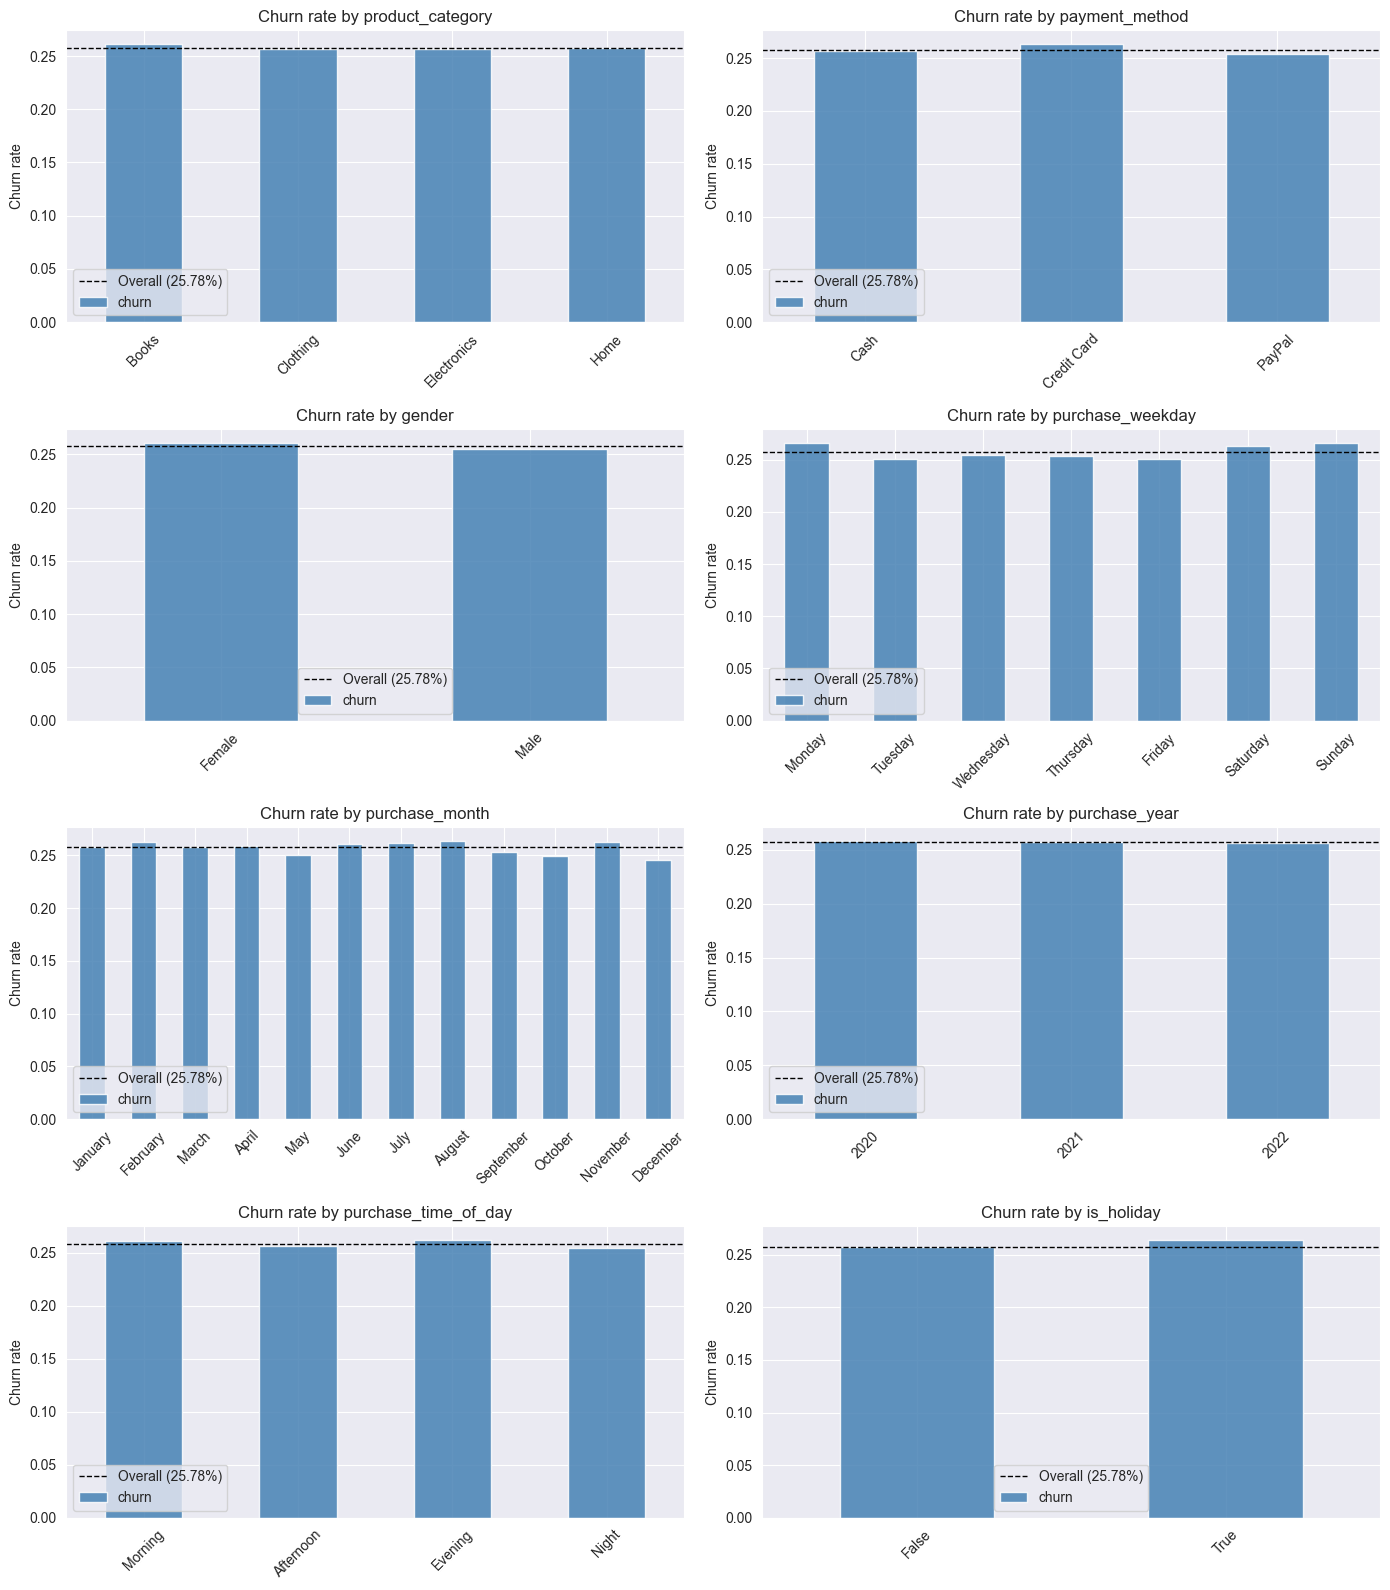


Customer counts per category:

--- product_category ---
product_category
Electronics    12335
Clothing       12214
Home           12136
Books          12068

--- payment_method ---
payment_method
Credit Card    16426
Cash           16206
PayPal         16121

--- gender ---
gender
Male      24482
Female    24271

--- purchase_weekday ---
purchase_weekday
Saturday     7045
Monday       7029
Thursday     7005
Wednesday    6997
Friday       6957
Tuesday      6867
Sunday       6853

--- purchase_month ---
purchase_month
January      7175
February     5993
March        5747
April        5034
May          4610
June         3946
July         3587
August       3386
September    2818
October      2413
November     2120
December     1924

--- purchase_year ---
purchase_year
2020    37010
2021     9668
2022     2075

--- purchase_time_of_day ---
purchase_time_of_day
Night        16145
Afternoon    12227
Morning      12222
Evening       8159

--- is_holiday ---
is_holiday
False    47497
True     

In [14]:
CAT_FEATS = ['product_category', 'payment_method', 'gender',
             'purchase_weekday', 'purchase_month', 'purchase_year',
             'purchase_time_of_day', 'is_holiday']

WEEKDAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER   = ['January', 'February', 'March', 'April', 'May', 'June',
                 'July', 'August', 'September', 'October', 'November', 'December']
TOD_ORDER     = ['Morning', 'Afternoon', 'Evening', 'Night']

ncols = 2
nrows = (len(CAT_FEATS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

overall_churn = customers['churn'].mean()

for ax, col in zip(axes, CAT_FEATS):
    rate = customers.groupby(col, observed=False)['churn'].mean()
    if col == 'purchase_weekday':
        rate = rate.reindex(WEEKDAY_ORDER)
    elif col == 'purchase_month':
        rate = rate.reindex(MONTH_ORDER)
    elif col == 'purchase_year':
        rate = rate.sort_index()
    elif col == 'purchase_time_of_day':
        rate = rate.reindex(TOD_ORDER)

    rate.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85)
    ax.axhline(overall_churn, color='black', linestyle='--', linewidth=1,
               label=f'Overall ({overall_churn:.2%})')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

for ax in axes[len(CAT_FEATS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print('\nCustomer counts per category:')
for col in CAT_FEATS:
    print(f'\n--- {col} ---')
    print(customers[col].value_counts().to_string())

## 5. Total Number of Purchases by Time Bucket

Total counts of 1st purchases (= customer acquisitions) bucketed by month, weekday and time-of-day.

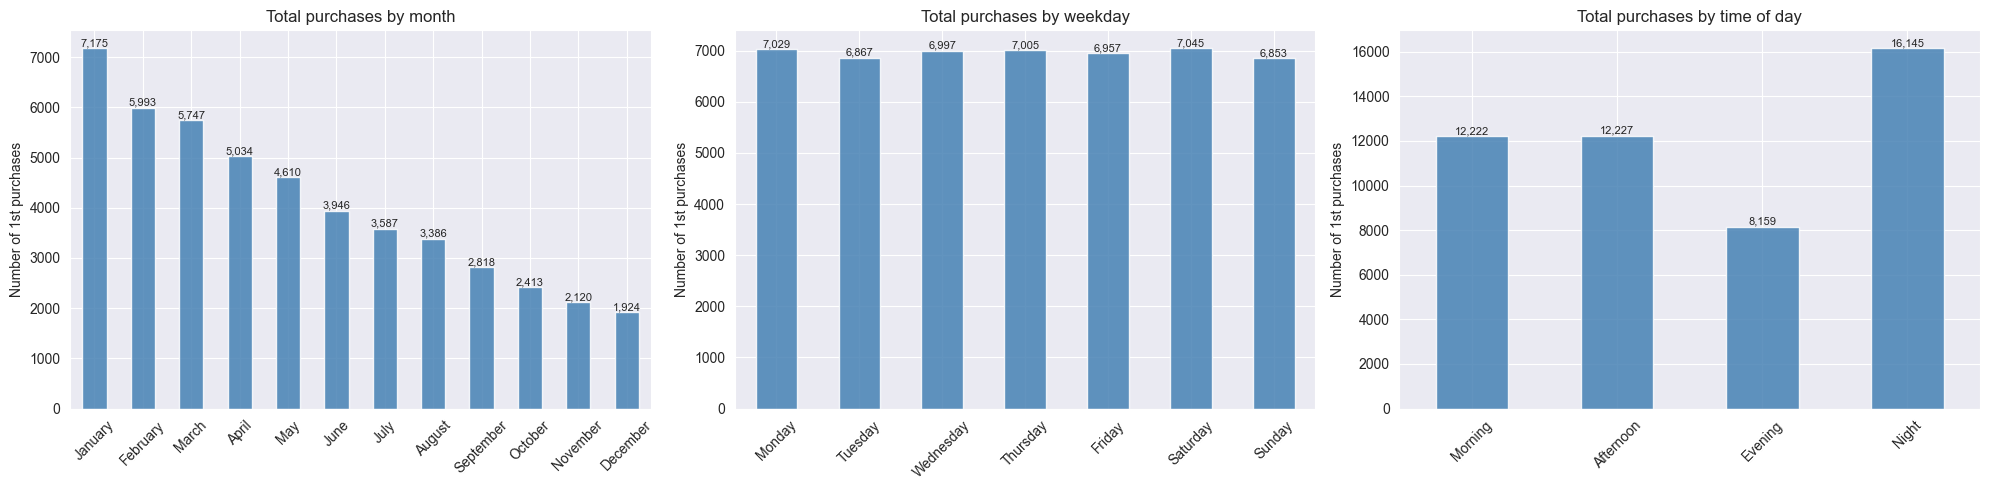


Counts table:

--- purchase_month ---
purchase_month
January      7175
February     5993
March        5747
April        5034
May          4610
June         3946
July         3587
August       3386
September    2818
October      2413
November     2120
December     1924

--- purchase_weekday ---
purchase_weekday
Monday       7029
Tuesday      6867
Wednesday    6997
Thursday     7005
Friday       6957
Saturday     7045
Sunday       6853

--- purchase_time_of_day ---
purchase_time_of_day
Morning      12222
Afternoon    12227
Evening       8159
Night        16145


In [20]:
COUNT_SPECS = [
    ('purchase_month',        MONTH_ORDER,   'Total purchases by month'),
    ('purchase_weekday',      WEEKDAY_ORDER, 'Total purchases by weekday'),
    ('purchase_time_of_day',  TOD_ORDER,     'Total purchases by time of day'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (col, order, title) in zip(axes, COUNT_SPECS):
    counts = customers[col].value_counts().reindex(order)
    counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85)
    ax.set_title(title)
    ax.set_ylabel('Number of 1st purchases')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print('\nCounts table:')
for col, order, _ in COUNT_SPECS:
    print(f'\n--- {col} ---')
    print(customers[col].value_counts().reindex(order).to_string())